# 1. Preprocessing

In [687]:
# Datensatz mit pandas laden
# CSV-Datei mit read_csv() einlesen und die ersten Zeilen anzeigen.
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [688]:
# Allgemeine Inspektion: describe / dtypes
# Wir überprüfen grundlegende Statistiken und Datentypen.
# Shape (Dimensionen) und Spalten
print(housing.shape)
print(housing.columns.tolist())
display(housing.describe()) # Deskriptive Statistiken
display(housing.dtypes) # Datentypen

(20640, 10)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [689]:
# Fehlende Werte (Missing Values) ~207 NaN
# Warum? Wir können kein Modell mit NaN-Werten trainieren. Wir imputieren mit dem Median (robuster gegenüber Ausreißern als der Mittelwert).
# Überprüfen, wie viele fehlende Werte existieren
print(housing.isnull().sum())

# Median berechnen und NaN-Werte ersetzen
median_bed = housing['total_bedrooms'].median()
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median_bed)

# Bestätigung
print(housing.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [690]:
# Wie viele Zeilen liegen am Cap (Obergrenze)?
cap = housing['median_house_value'].max()
n_capped = (housing['median_house_value'] == cap).sum()
print(f"Zeilen am Cap ({cap}): {n_capped}")

# Gedeckelte Zeilen entfernen
# Wir entfernen die Werte bei 500.001 $, da diese die statistische Verteilung verzerren.
housing_clean = housing[
    housing['median_house_value'] < cap
].copy()

print(f"Verbleibende Zeilen: {len(housing_clean)}")

Zeilen am Cap (500001.0): 965
Verbleibende Zeilen: 19675


In [691]:
# Datentyp: Category
# Die Spalte 'ocean_proximity' ist Text (Object), repräsentiert aber eine begrenzte Anzahl an Kategorien.
# Wir konvertieren sie in den Datentyp 'category' für bessere Effizienz und Korrektheit.
housing_clean['ocean_proximity'] = \
    housing_clean['ocean_proximity'].astype('category')

# Überprüfung der Kategorien-Häufigkeit und des Datentyps
print(housing_clean['ocean_proximity'].value_counts())
print(housing_clean['ocean_proximity'].dtype)

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64
category


In [692]:
# Trennung von Features (X) und Zielvariable (y)
# Der Hauspreis (median_house_value) ist das, was wir vorhersagen wollen — wir extrahieren ihn separat in y.
# Alle anderen Spalten werden zu Merkmalen (Features) in X.

# y = Zielvariable (was vorhergesagt werden soll)
y = housing_clean['median_house_value']

# X = alle anderen Spalten (Merkmale)
X = housing_clean.drop(columns=['median_house_value'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nSpalten in X: {X.columns.tolist()}")

X shape: (19675, 9)
y shape: (19675,)

Spalten in X: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [693]:
# One-Hot-Encoding für ocean_proximity
# ML-Modelle können nicht mit Text arbeiten. Wir konvertieren 'ocean_proximity' mit get_dummies() in numerische Spalten.
# drop_first=True entfernt eine redundante Spalte, um Multikollinearität (Dummy Variable Trap) zu vermeiden.

# Überprüfen, ob 'ocean_proximity' vor der Codierung in X vorhanden ist
print("Spalten vor der Codierung:", X.columns.tolist())

# One-Hot-Encoding — funktioniert sowohl mit 'object' als auch mit 'category' Datentypen
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

print("Spalten nach der Codierung:", X.columns.tolist())
print(f"X-Shape nach der Codierung: {X.shape}")

Spalten vor der Codierung: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Spalten nach der Codierung: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
X-Shape nach der Codierung: (19675, 12)


In [694]:
# Train / Test Split 80% / 20%
# Wir trainieren das Modell auf X_train / y_train und evaluieren es auf X_test / y_test.
# random_state=42 stellt die Reproduzierbarkeit der Ergebnisse sicher.
# stratify=None, da y eine kontinuierliche Variable ist (Regression) — eine Stratifizierung ist hier nicht anwendbar.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (15740, 12)
X_test:  (3935, 12)
y_train: (15740,)
y_test:  (3935,)


In [695]:
# Normalisierung mit StandardScaler
# Merkmale (Features) haben sehr unterschiedliche Skalen (z. B. median_income 1-15 vs. total_rooms 1-40.000).
# Der StandardScaler subtrahiert den Mittelwert und dividiert durch die Standardabweichung → alle in denselben Bereich.
# WICHTIG: fit_transform nur auf Train, transform auf Test — sonst "sieht" das Modell Testdaten (Data Leakage)!
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform auf Train: lernt Mittelwert (Mean) und Standardabweichung (Std) AUS DEM TRAINING
X_train_scaled = scaler.fit_transform(X_train)

# Nur transform auf Test: wendet denselben Mittelwert/Std an — KEIN erneutes Fit!
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("Mittelwert (sollte ~0 sein):", X_train_scaled.mean(axis=0).round(2))
print("Standardabweichung (sollte ~1 sein):", X_train_scaled.std(axis=0).round(2))

X_train_scaled shape: (15740, 12)
Mittelwert (sollte ~0 sein): [-0.  0. -0. -0.  0.  0. -0.  0.  0.  0. -0.  0.]
Standardabweichung (sollte ~1 sein): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


y_train Statistiken:
count     15740.0
mean     192191.0
std       97166.0
min       14999.0
25%      116700.0
50%      174100.0
75%      247600.0
max      500000.0
Name: median_house_value, dtype: float64

y_test Statistiken:
count      3935.0
mean     193625.0
std       99868.0
min       14999.0
25%      116200.0
50%      171800.0
75%      251550.0
max      500000.0
Name: median_house_value, dtype: float64


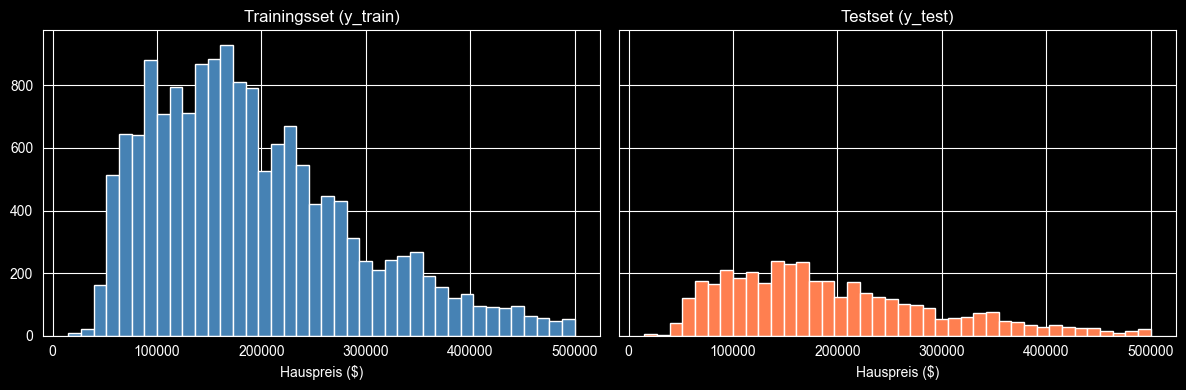

In [696]:
# Abschließende Überprüfung des Splits
# Wir stellen sicher, dass die Verteilung von y in Train und Test ähnlich ist — wir wollen vermeiden, dass alle teuren Häuser nur im Training landen.
# Vergleich der Statistiken: y_train vs. y_test
print("y_train Statistiken:")
print(y_train.describe().round(0))

print("\ny_test Statistiken:")
print(y_test.describe().round(0))

# Side-by-Side Visualisierung der Histogramme
# Dies dient zur optischen Kontrolle der Preisverteilung in beiden Datensätzen.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Histogramm für das Trainingsset
ax1.hist(y_train, bins=40, color='steelblue')
ax1.set_title('Trainingsset (y_train)')
ax1.set_xlabel('Hauspreis ($)')

# Histogramm für das Testset
ax2.hist(y_test, bins=40, color='coral')
ax2.set_title('Testset (y_test)')
ax2.set_xlabel('Hauspreis ($)')

plt.tight_layout()
plt.show()

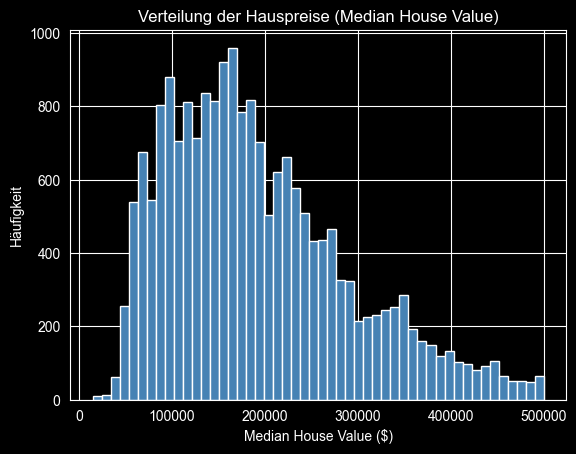

In [697]:
# Histogramm — Verteilung der Hauswerte
# Analog zum Histogramm der Noten aus der Übung im Unterricht.
plt.hist(
    housing_clean['median_house_value'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Median House Value ($)')
plt.ylabel('Häufigkeit')
plt.title('Verteilung der Hauspreise (Median House Value)')
plt.show()

# 2. Variablenauswahl

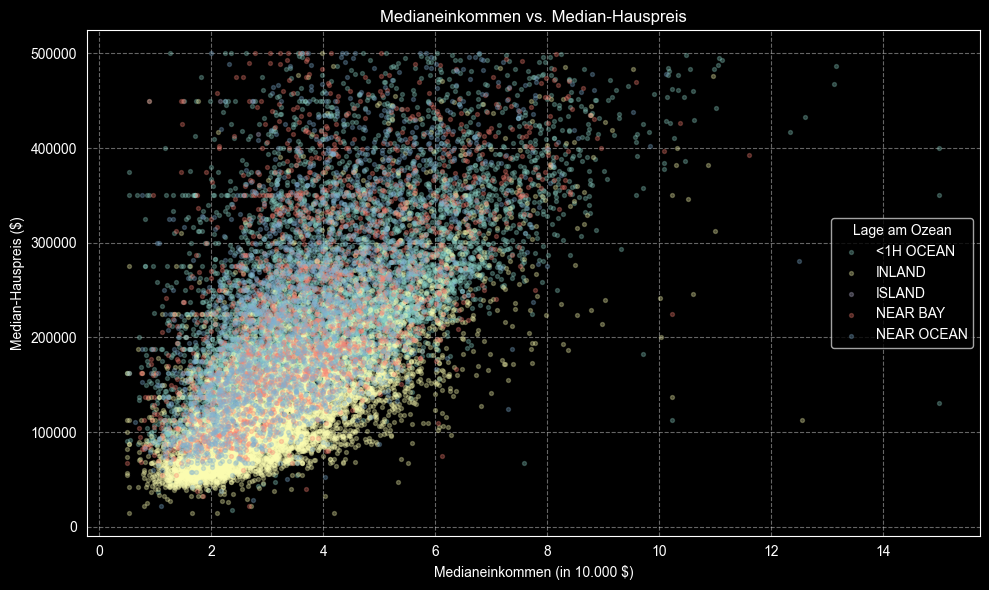

In [698]:
# Scatter-Plot — Einkommen vs. Hauswert
# Visualisierung des Zusammenhangs zwischen Medianeinkommen und Hauspreis.
plt.figure(figsize=(10, 6))

# Wir gruppieren nach 'ocean_proximity', um verschiedene Kategorien farblich hervorzuheben.
for name, group in housing_clean.groupby('ocean_proximity', observed=True):
    plt.scatter(
        group['median_income'],
        group['median_house_value'],
        label=name,
        alpha=0.3,
        s=8
    )

plt.xlabel('Medianeinkommen (in 10.000 $)')
plt.ylabel('Median-Hauspreis ($)')
plt.title('Medianeinkommen vs. Median-Hauspreis')
plt.legend(title='Lage am Ozean')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

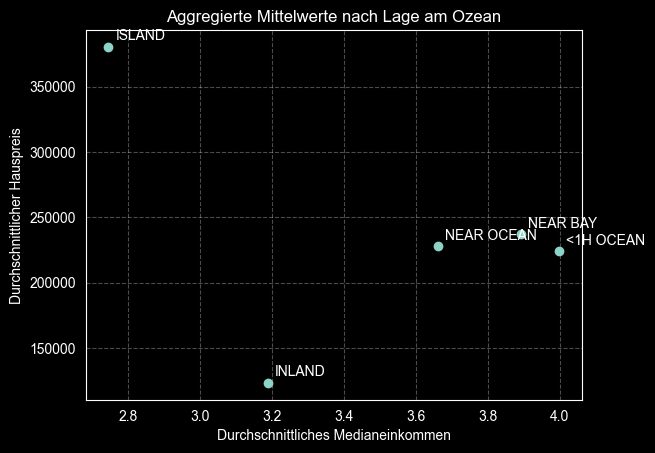

In [699]:
# Gruppierung mit groupby
# Analog zur Aggregation nach Studenten. Wir gruppieren nach 'ocean_proximity' und berechnen den Mittelwert.
grouped = housing_clean.groupby('ocean_proximity', observed=True).mean(numeric_only=True)

# Scatter-Plot der aggregierten Daten
plt.scatter(
    grouped['median_income'],
    grouped['median_house_value']
)

# Beschriftung der einzelnen Punkte mit dem Gruppennamen
for name, row in grouped.iterrows():
    plt.annotate(name,
        (row['median_income'], row['median_house_value']),
        xytext=(5, 5), textcoords='offset points'
    )

plt.title('Aggregierte Mittelwerte nach Lage am Ozean')
plt.xlabel('Durchschnittliches Medianeinkommen')
plt.ylabel('Durchschnittlicher Hauspreis')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

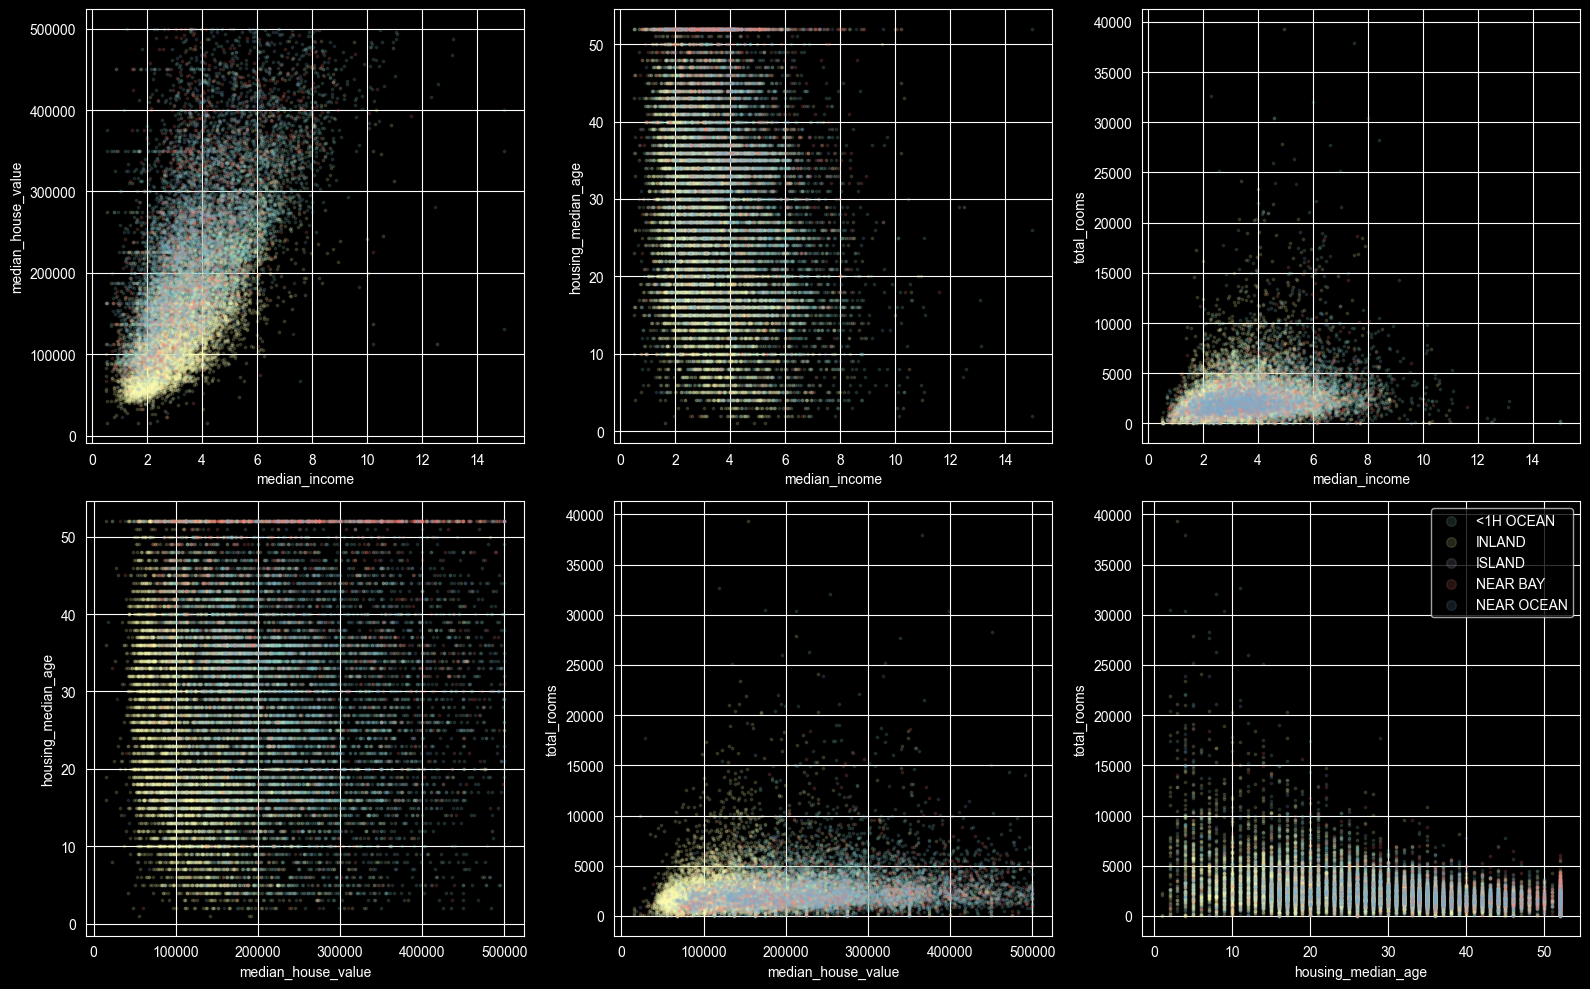

In [700]:
# Scatter-Matrix — alle Merkmalskombinationen
# Analog zur Iris-Scatter-Matrix. Wir iterieren mit itertools.combinations und färben nach 'ocean_proximity'.
import itertools

features = [
    'median_income', 'median_house_value',
    'housing_median_age', 'total_rooms'
]
combinations = list(itertools.combinations(features, 2))

fig = plt.figure(figsize=(16, 10))

for i, combo in enumerate(combinations, 1):
    axs = fig.add_subplot(2, 3, i)
    for name, group in housing_clean.groupby('ocean_proximity', observed=True):
        axs.scatter(
            group[combo[0]], group[combo[1]],
            label=name, alpha=0.15, s=3
        )
    axs.set_xlabel(combo[0])
    axs.set_ylabel(combo[1])

plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

### 2.1 Geografische Visualisierung (Die Preis-Landkarte)

Da unser Datensatz geografische Koordinaten (`latitude` und `longitude`) enthält, können wir die Daten nutzen, um eine Landkarte von Kalifornien nachzubilden.

Im folgenden Streudiagramm (Scatter Plot) repräsentiert:
* **Die Position** eines Punktes die geografische Lage eines Bezirks.
* **Die Größe** des Punktes (`s`) die Bevölkerungsdichte (`population`).
* **Die Farbe** des Punktes (`c`) den mittleren Hauspreis (`median_house_value`), wobei rote Farben für sehr teure und blaue Farben für günstigere Gegenden stehen.

Diese Visualisierung ist entscheidend, da sie visuell beweist, dass die Immobilienpreise extrem stark von der Lage abhängen (insbesondere von der Nähe zur Küste und zu den Wirtschaftszentren Los Angeles und San Francisco).

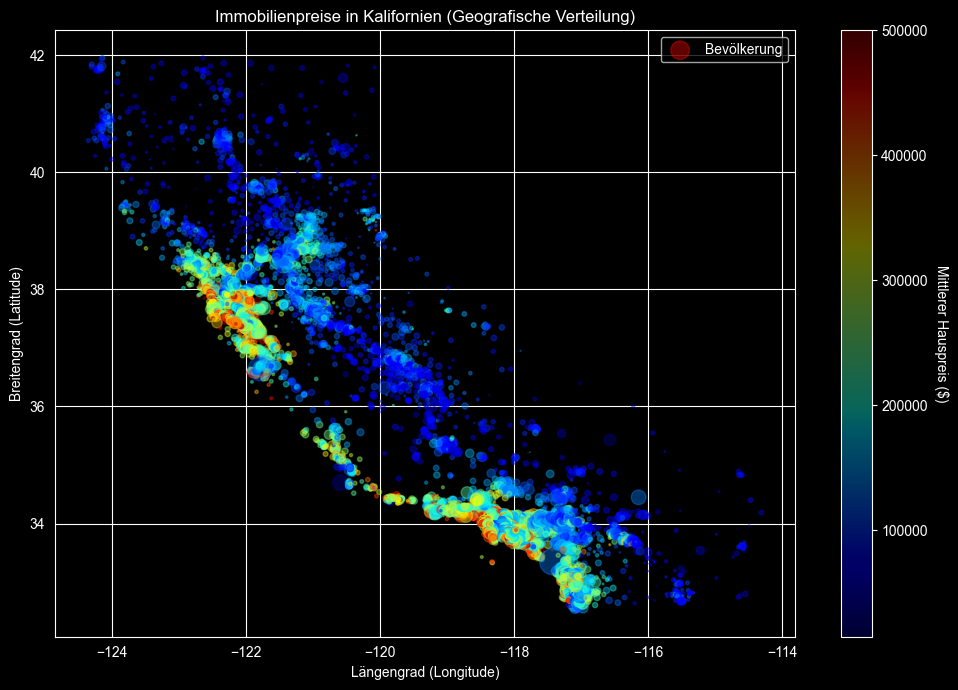

In [701]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Wir nutzen die bereinigten Daten der Kollegin (housing_clean)
plt.figure(figsize=(10, 7))

# Erstellen des Scatter-Plots, der die Karte von Kalifornien nachbildet
scatter = plt.scatter(
    x=housing_clean['longitude'],
    y=housing_clean['latitude'],
    alpha=0.4,
    s=housing_clean['population'] / 100,  # Punktgröße = Population
    c=housing_clean['median_house_value'], # Punktfarbe = Hauspreis
    cmap='jet',                            # Farbskala (Blau=günstig, Rot=teuer)
    label='Bevölkerung'
)

# Hinzufügen einer Farblegende für die Preise
cbar = plt.colorbar(scatter)
cbar.set_label('Mittlerer Hauspreis ($)', rotation=270, labelpad=15)

plt.xlabel('Längengrad (Longitude)')
plt.ylabel('Breitengrad (Latitude)')
plt.title('Immobilienpreise in Kalifornien (Geografische Verteilung)')
plt.legend()
plt.tight_layout()
plt.show()

## 2.2 Räumliche Merkmale

Wie unsere explorative Datenanalyse (EDA) gezeigt hat, ist die geografische Lage der wichtigste Faktor für den Immobilienpreis. Mathematische Modelle haben jedoch oft Schwierigkeiten, rohe Koordinaten (Breiten- und Längengrad) optimal zu interpretieren.

Um unserem Modell zu helfen, extrahieren wir **räumliche Merkmale**:
1. **Entfernung zu Metropolen:** Wir berechnen die direkte (euklidische) Distanz zu den Wirtschaftszentren Los Angeles und San Francisco.
2. **Geografisches Clustering:** Wir verwenden den **K-Means-Algorithmus** aus dem Bereich *Unsupervised Learning*, um die Koordinaten in 15 Makro-Regionen (Nachbarschaften) zu unterteilen.
3. **Logische Kennzahlen (Ratios):** Wir erstellen neue, aussagekräftigere Variablen wie "Zimmer pro Haushalt" anstelle der absoluten Zimmeranzahl.

In [702]:
import numpy as np
from sklearn.cluster import KMeans

# 1. Entfernung zu den Wirtschaftszentren berechnen
LA_COORDS = (34.0522, -118.2437)
SF_COORDS = (37.7749, -122.4194)

housing_clean["dist_to_LA"] = np.sqrt((housing_clean["latitude"] - LA_COORDS[0])**2 + (housing_clean["longitude"] - LA_COORDS[1])**2)
housing_clean["dist_to_SF"] = np.sqrt((housing_clean["latitude"] - SF_COORDS[0])**2 + (housing_clean["longitude"] - SF_COORDS[1])**2)

# 2. Logische Verhältnisse (Ratios) erstellen
housing_clean["rooms_per_household"] = housing_clean["total_rooms"] / housing_clean["households"]
housing_clean["bedrooms_per_room"] = housing_clean["total_bedrooms"] / housing_clean["total_rooms"]
housing_clean["population_per_household"] = housing_clean["population"] / housing_clean["households"]

# 3. K-Means Clustering für geografische Zonen
# Wir nutzen n_init='auto' für neuere scikit-learn Versionen
kmeans = KMeans(n_clusters=15, n_init=10, random_state=42)
housing_clean["geo_cluster"] = kmeans.fit_predict(housing_clean[["longitude", "latitude"]])

# Konvertierung in String, damit es später vom OneHotEncoder als Kategorie erkannt wird
housing_clean["geo_cluster"] = housing_clean["geo_cluster"].astype(str)

print("Neue Merkmale erfolgreich hinzugefügt!")
print(housing_clean.head(3))
print(50*"-")
print(housing_clean.shape)

Neue Merkmale erfolgreich hinzugefügt!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   

   population  households  median_income  median_house_value ocean_proximity  \
0       322.0       126.0         8.3252            452600.0        NEAR BAY   
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY   
2       496.0       177.0         7.2574            352100.0        NEAR BAY   

   dist_to_LA  dist_to_SF  rooms_per_household  bedrooms_per_room  \
0    5.526540    0.216606             6.984127           0.146591   
1    5.505479    0.216800             6.238137           0.155797   
2    5.513048    0.194485             8.288136           0.129516   

   population_per_household geo_cluster  
0                  2

### 2.3 Visualisierung der geografischen Cluster (K-Means)

Um zu überprüfen, ob unser K-Means-Algorithmus sinnvolle geografische Zonen gebildet hat, visualisieren wir die 15 neu erstellten Makro-Regionen auf der Karte.
Jeder Bezirk (Datenpunkt) ist nun in einer Farbe eingefärbt, die seinem jeweiligen Cluster entspricht. Wie wir sehen können, hat der Algorithmus die Form Kaliforniens selbstständig erkannt und logische, zusammenhängende Regionen (wie z.B. die Bay Area, den Großraum Los Angeles oder das Landesinnere) identifiziert. Dies hilft den nachfolgenden Modellen massiv, lokale Preistrends zu verstehen.

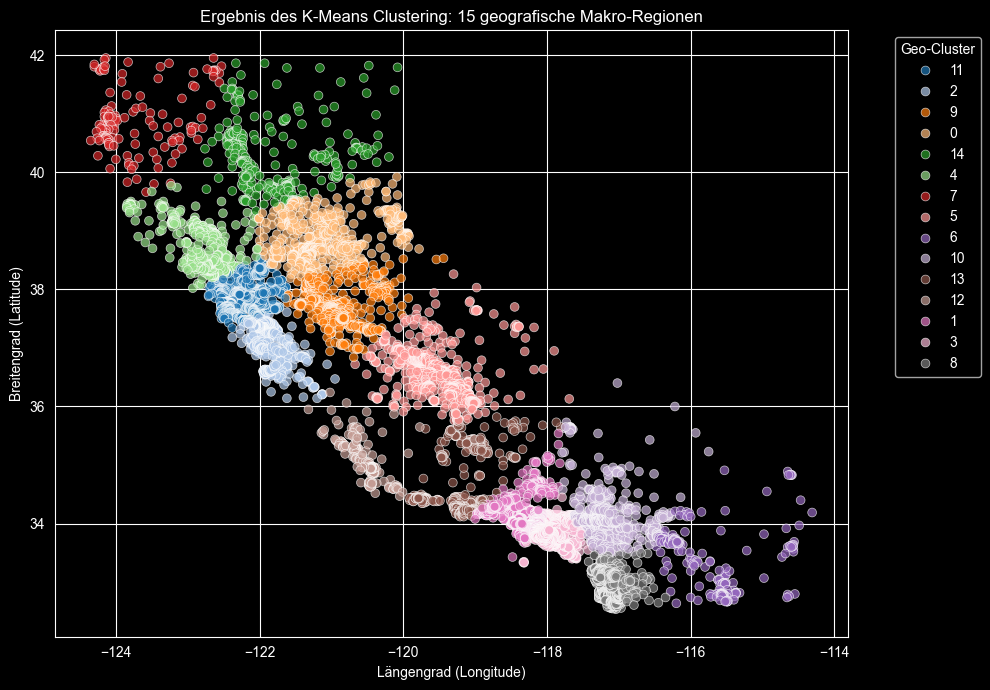

In [703]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# Wir nutzen Seaborn, da es kategorische Daten (unsere als String gespeicherten Cluster)
# automatisch mit einer passenden Farbpalette (tab20) versieht.
sns.scatterplot(
    data=housing_clean,
    x='longitude',
    y='latitude',
    hue='geo_cluster',
    palette='tab20',   # tab20 bietet 20 deutliche Farben (perfekt für unsere 15 Cluster)
    s=40,              # Punktgröße
    alpha=0.7,         # Leichte Transparenz
    legend='full'
)

plt.title('Ergebnis des K-Means Clustering: 15 geografische Makro-Regionen')
plt.xlabel('Längengrad (Longitude)')
plt.ylabel('Breitengrad (Latitude)')

# Legende ordentlich außerhalb des Graphen platzieren
plt.legend(title='Geo-Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 3. Automatisierte Preprocessing-Pipeline

Anstatt Skalierung und Encoding manuell durchzuführen, fassen wir alle Preprocessing-Schritte in einer **Pipeline** zusammen. Dies verhindert *Data Leakage* und ermöglicht es uns, später verschiedene Modelle schnell auszuprobieren. Wir definieren den Split in Trainings- und Testdaten hier neu, um unsere neu erstellten Features zu integrieren.

In [704]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Zielvariable (y) und Features (X) trennen
X = housing_clean.drop("median_house_value", axis=1)
y = housing_clean["median_house_value"]

# Train-Test-Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Spaltentypen identifizieren
num_features = X_train.drop(["ocean_proximity", "geo_cluster"], axis=1).columns.tolist()
cat_features = ["ocean_proximity", "geo_cluster"]

# Pipeline für numerische Merkmale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Pipeline für kategorische Merkmale
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Zusammenführung im ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Wir transformieren die Trainingsdaten einmal vorab für das Benchmarking
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"Form der Trainingsdaten nach der Pipeline: {X_train_prepared.shape}")

Form der Trainingsdaten nach der Pipeline: (15740, 33)


## 4. Einzelauswertung der fortgeschrittenen Modelle (Visualisierung)

Bevor wir alle Modelle in einem großen Benchmark miteinander vergleichen, analysieren wir die restlichen Algorithmen aus der Vorlesung zunächst einzeln.
Genau wie bei der Linearen Regression und dem KNN unseres Teams, erstellen wir für jedes Modell ein **Streudiagramm (Scatter Plot)**, das die tatsächlichen Immobilienpreise den vorhergesagten Preisen gegenüberstellt. Die rote gestrichelte Linie ($y=x$) markiert die perfekte Vorhersage.

Um den Code effizient und sauber zu halten, definieren wir zunächst eine Hilfsfunktion für die Erstellung der Graphen.

In [705]:
from sklearn.metrics import mean_absolute_error, r2_score

# Hilfsfunktion zur Visualisierung der Modellergebnisse
def plot_actual_vs_predicted(y_true, y_pred, model_name, plot_color):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, color=plot_color, label=f'{model_name} Vorhersagen')

    # Rote Linie für die perfekte Vorhersage
    line_coords = [y_true.min(), y_true.max()]
    plt.plot(line_coords, line_coords, color='#c0392b', linestyle='--', linewidth=2, label='Perfekte Vorhersage ($y=x$)')

    plt.title(f'{model_name}: Tatsächliche vs. Vorhergesagte Hauspreise \n RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R²: {r2:.3f}')
    plt.xlabel('Tatsächlicher Preis ($)')
    plt.ylabel('Vorhergesagter Preis ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 4.1 Lineare Regression

Als Basismodell verwenden wir die einfache Lineare Regression. Dieses Modell versucht, eine lineare Beziehung zwischen den Merkmalen (Features) und dem Hauspreis zu finden. Es dient als Referenzpunkt (Baseline), um zu sehen, wie viel komplexere Modelle die Vorhersage verbessern können.

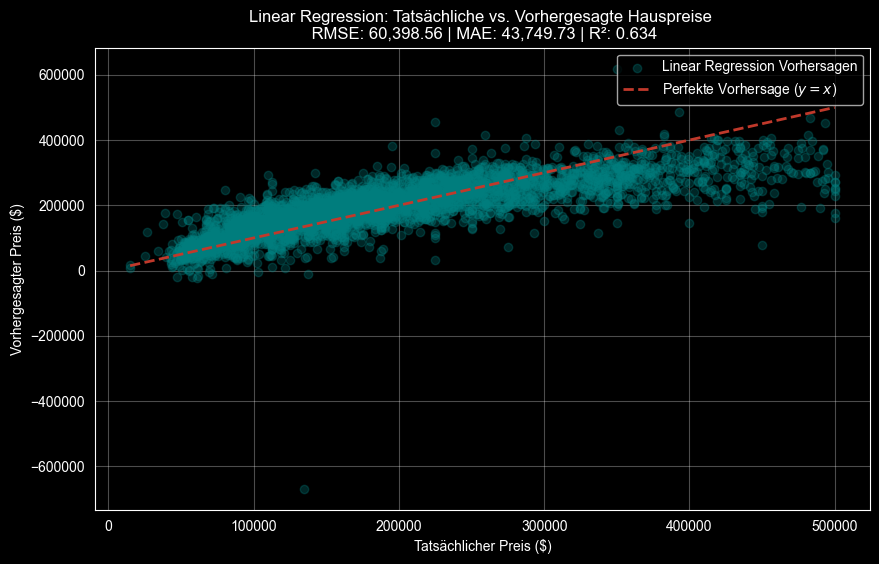

In [706]:
# linear progression

from sklearn.linear_model import LinearRegression

# 1. Modell initialisieren
lr_model = LinearRegression()

# 2. Modell trainieren
lr_model.fit(X_train_prepared, y_train)

# 3. Vorhersagen treffen
lr_predictions = lr_model.predict(X_test_prepared)

# 4. Visualisierung mit der Hilfsfunktion aufrufen
plot_actual_vs_predicted(y_test, lr_predictions, 'Linear Regression', 'teal')

## 4.2 K-Nearest Neighbors (KNN) Regression

Der KNN-Algorithmus trifft Vorhersagen basierend auf der Ähnlichkeit zu den nächsten Datenpunkten (Nachbarn). Da die Wahl der Anzahl der Nachbarn ($K$) entscheidend für die Genauigkeit ist, führen wir eine Schleife durch, um das optimale $K$ mit dem geringsten mittleren absoluten Fehler (MAE) zu finden.

The best K is 11 with an MAE of $36,783.55


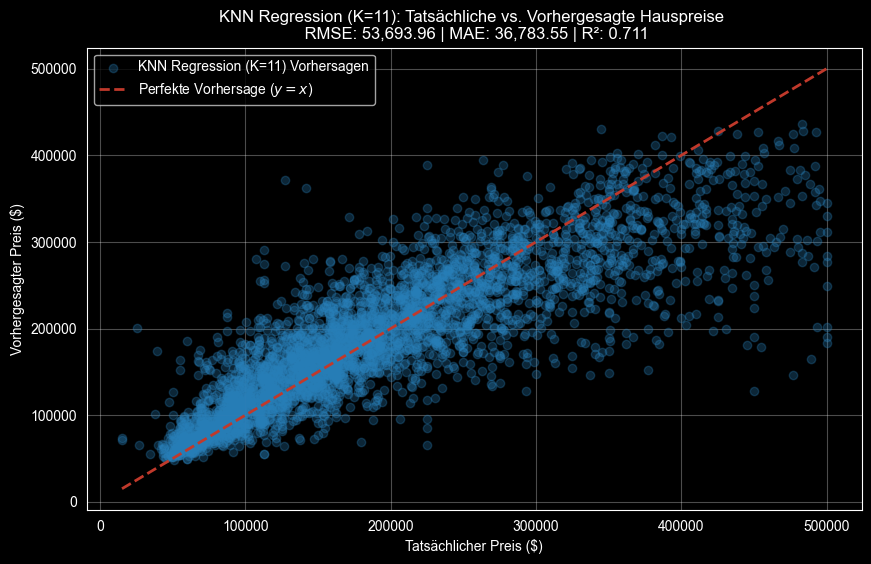

In [707]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

best_error = float('inf')
best_k = 0

# find the best k for knn
for current_neighbors in range(1, 18):
    knn_model = KNeighborsRegressor(current_neighbors)
    knn_model.fit(X_train_prepared, y_train)
    knn_predictions = knn_model.predict(X_test_prepared)

    current_error = mean_absolute_error(y_test, knn_predictions)

    if current_error <= best_error:
        best_error = current_error
        best_k = current_neighbors

print(f"The best K is {best_k} with an MAE of ${best_error:,.2f}")

# Finales Modell mit dem besten K trainieren
knn_model = KNeighborsRegressor(best_k)
knn_model.fit(X_train_prepared, y_train)
knn_predictions = knn_model.predict(X_test_prepared)

# Visualisierung mit der Hilfsfunktion aufrufen
plot_actual_vs_predicted(y_test, knn_predictions, f'KNN Regression (K={best_k})', '#2980b9')

### 4.3 Decision Tree Regressor (Entscheidungsbaum)
Der Entscheidungsbaum lernt einfache Wenn-Dann-Regeln. Er neigt jedoch dazu, die Trainingsdaten auswendig zu lernen (Overfitting), was oft zu einer breiten Streuung bei neuen Testdaten führt.

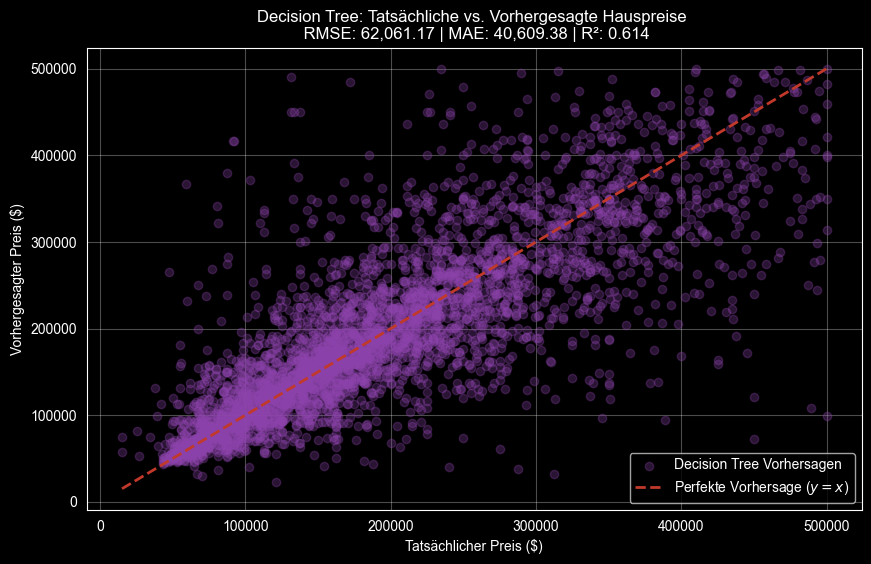

In [708]:
from sklearn.tree import DecisionTreeRegressor

# Modell initialisieren und trainieren
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_prepared, y_train)

# Vorhersagen treffen
tree_predictions = tree_model.predict(X_test_prepared)

# Visualisieren
plot_actual_vs_predicted(y_test, tree_predictions, 'Decision Tree', '#8e44ad') # Lila

### 4.4 Support Vector Regression (SVR)
SVR versucht, einen "Toleranzschlauch" um die Datenpunkte zu legen. Bei sehr großen Datensätzen wie unserem ist SVR jedoch sehr rechenintensiv und hat ohne perfektes Hyperparameter-Tuning Schwierigkeiten, die Ausreißer (sehr teure Häuser) zu erfassen.

Trainiere SVR... (Dies kann ca. 1 Minute dauern)


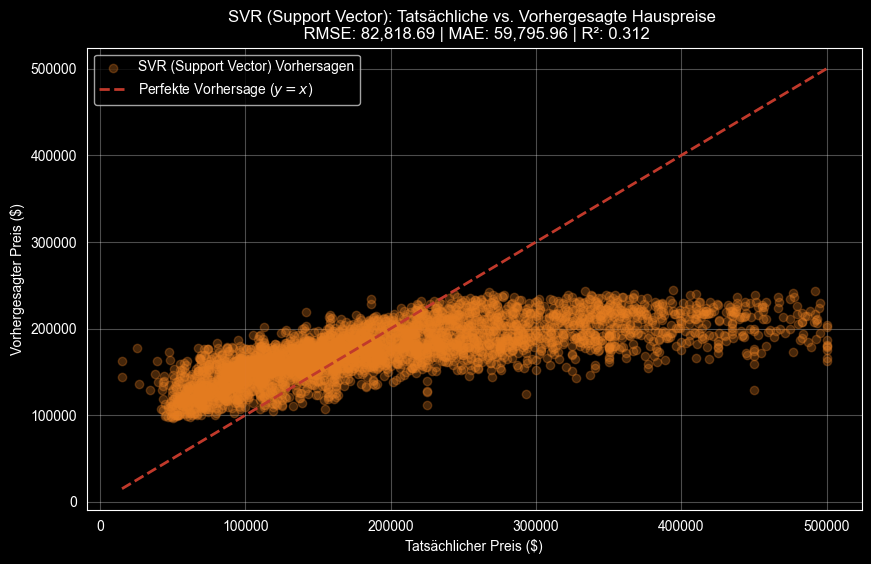

In [709]:
from sklearn.svm import SVR

print("Trainiere SVR... (Dies kann ca. 1 Minute dauern)")
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train_prepared, y_train)

svr_predictions = svr_model.predict(X_test_prepared)

plot_actual_vs_predicted(y_test, svr_predictions, 'SVR (Support Vector)', '#e67e22') # Orange

### 4.5 Neuronales Netz (MLP Regressor)
Ein Multi-Layer Perceptron (MLP) ist ein künstliches neuronales Netz. Während sie bei Bildern stark sind, haben Standard-MLPs bei tabellarischen Daten oft Probleme mit der Konvergenz, was sich in einer instabilen Punktewolke zeigt.

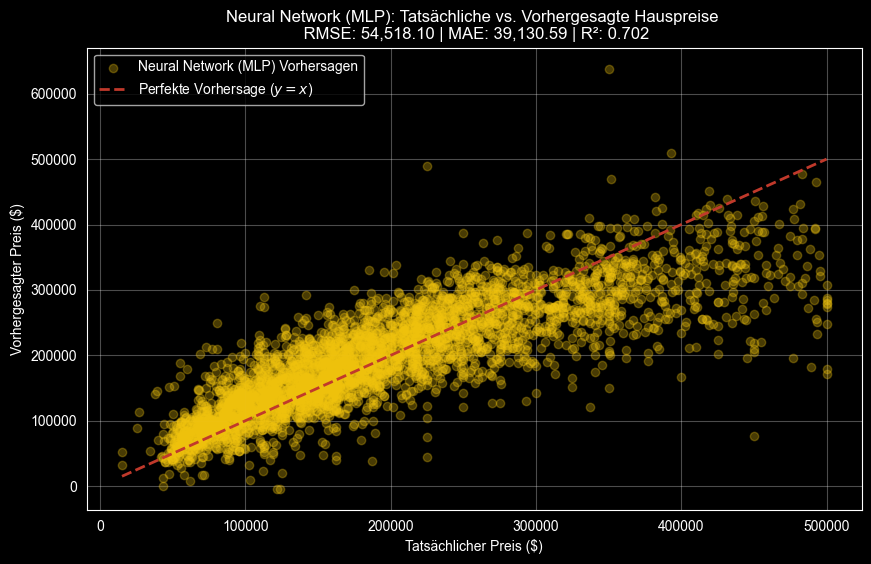

In [710]:
from sklearn.neural_network import MLPRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning

# Warnungen für das Notebook unterdrücken, da wir wissen, dass das MLP hier sein Limit erreicht
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
mlp_model.fit(X_train_prepared, y_train)

mlp_predictions = mlp_model.predict(X_test_prepared)

plot_actual_vs_predicted(y_test, mlp_predictions, 'Neural Network (MLP)', '#f1c40f') # Gelb

### 4.6 Random Forest (Ensemble)
Hier sehen wir die Kraft von Ensemble-Methoden. Der Random Forest kombiniert Hunderte von Entscheidungsbäumen. Die Vorhersagen (Punkte) schmiegen sich viel dichter an die rote Linie, was auf eine stark verbesserte Genauigkeit hinweist.

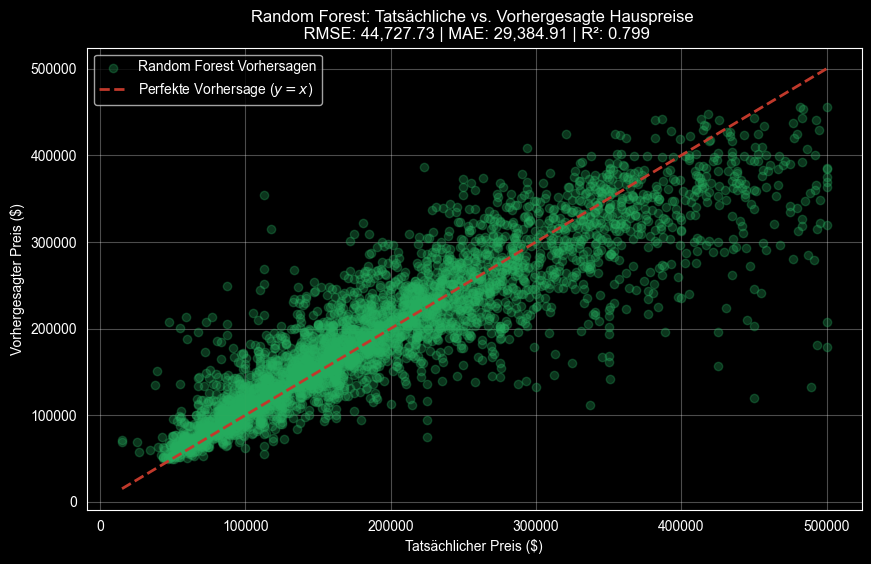

In [711]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_prepared, y_train)

rf_predictions = rf_model.predict(X_test_prepared)

plot_actual_vs_predicted(y_test, rf_predictions, 'Random Forest', '#27ae60') # Grün

### 4.7 Gradient Boosting (Ensemble)
Gradient Boosting baut Bäume sequenziell auf, wobei jeder neue Baum die Fehler seiner Vorgänger korrigiert. Zusammen mit Random Forest zeigt dieses Modell visuell die beste Übereinstimmung (dichteste Punktewolke entlang $y=x$).

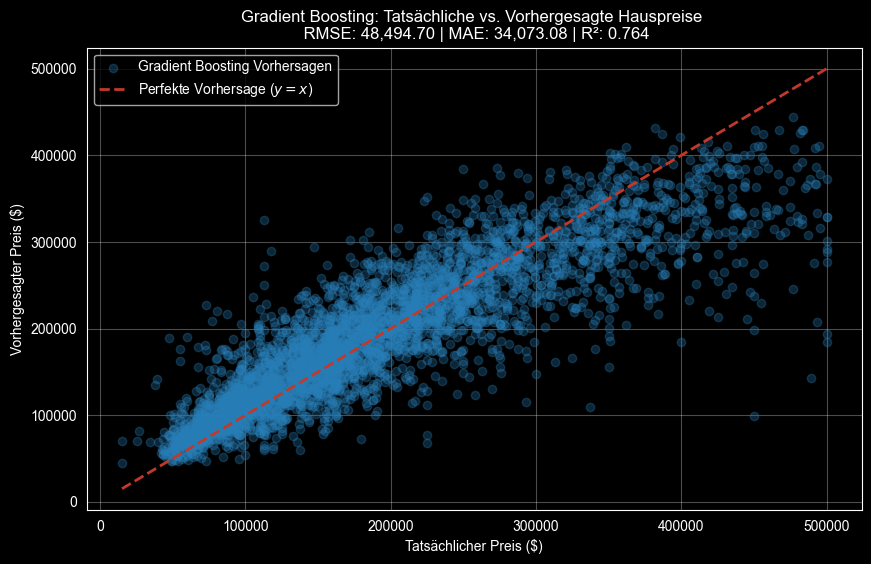

In [712]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_prepared, y_train)

gb_predictions = gb_model.predict(X_test_prepared)

plot_actual_vs_predicted(y_test, gb_predictions, 'Gradient Boosting', '#2980b9') # Blau

## 5. Modellvergleich und Ensemble-Methoden (Benchmarking)

In diesem entscheidenden Schritt vergleichen wir die Basismodelle (Lineare Regression und KNN) mit den fortgeschrittenen Algorithmen aus der Vorlesung.

Zusätzlich implementieren wir ein **Stacking-Modell** (Gestapelte Generalisierung).
* **Level-0 Modelle:** Vorhersagen der Linearen Regression, des KNN und eines Entscheidungsbaums.
* **Level-1 Modell (Meta-Modell):** Ein übergeordneter Regressor (Ridge) lernt, wie er diese Vorhersagen optimal kombiniert.

Alle Modelle werden mit einer **5-Fold Cross-Validation** evaluiert. Die Zielvariable wird während des Trainings logarithmisch transformiert (`TransformedTargetRegressor`), um die asymmetrische Preisverteilung auszugleichen.

Starte Cross-Validation Benchmarking ...
-----------------------------------------------------------------
Linear Regression         | R²: 0.5733 (±0.053) | 1.7s
KNN                       | R²: 0.6858 (±0.008) | 1.3s
Decision Tree             | R²: 0.6033 (±0.008) | 1.4s
SVR                       | R²: 0.6857 (±0.027) | 51.8s
Neural Network (MLP)      | R²: -141.0566 (±283.410) | 3.6s
Random Forest             | R²: 0.7914 (±0.007) | 9.0s
Gradient Boosting         | R²: 0.7476 (±0.006) | 3.4s
Stacking Ensemble         | R²: 0.7362 (±0.006) | 1.4s
-----------------------------------------------------------------


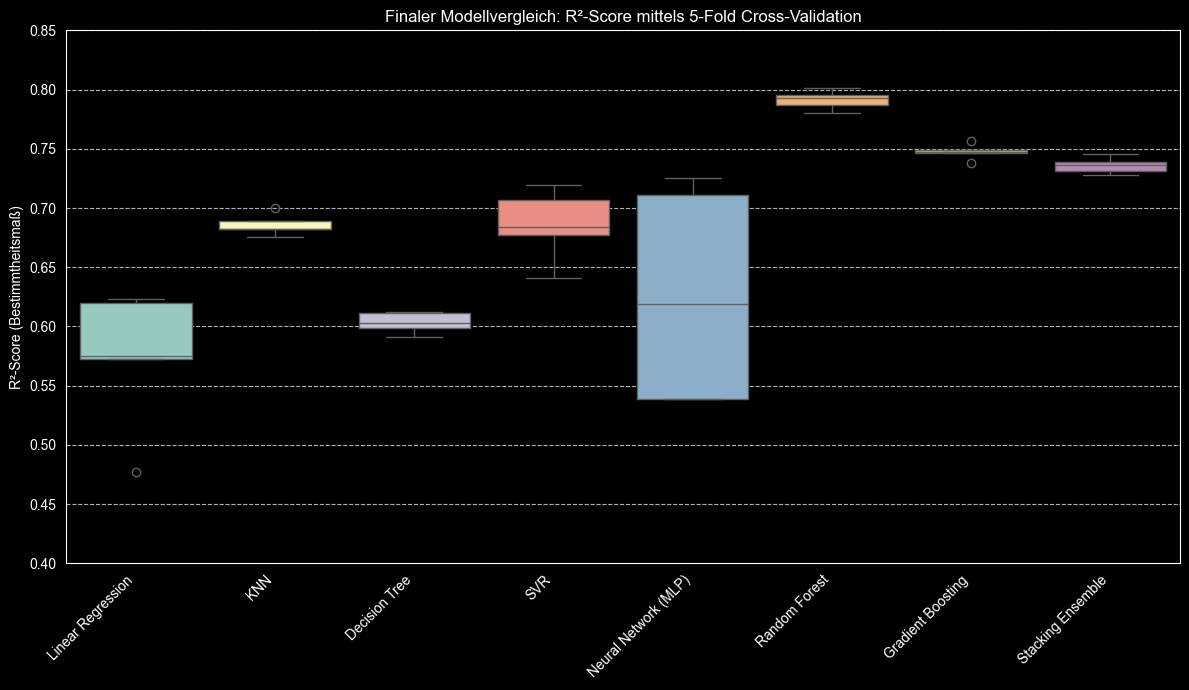

In [714]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Definition der Basis-Modelle
base_models = {
    "Linear Regression": LinearRegression(),
    f"KNN": KNeighborsRegressor(n_neighbors=best_k),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
}

# 2. Definition des Stacking Ensembles (Kombination aus Linear, KNN und Tree)
stacking_estimators = [
    ('lr', base_models["Linear Regression"]),
    ('knn', base_models["KNN"]),
    ('dt', base_models["Decision Tree"])
]
stacking_ensemble = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(),
    cv=5
)

# 3. Alle Modelle in eine Liste für das Benchmarking aufnehmen
all_models = base_models.copy()
all_models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42)
all_models["Gradient Boosting"] = GradientBoostingRegressor(n_estimators=100, random_state=42)
all_models["Stacking Ensemble"] = stacking_ensemble

results = []
names = []

print("Starte Cross-Validation Benchmarking ...\n" + "-"*65)

for name, model in all_models.items():
    start_time = time.time()

    # Wir wenden die Log-Transformation auf das Ziel an, um die Ergebnisse zu stabilisieren
    log_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # Durchführung der Cross-Validation
    cv_scores = cross_val_score(log_model, X_train_prepared, y_train, cv=5, scoring='r2', n_jobs=-1)

    execution_time = time.time() - start_time
    results.append(cv_scores)
    names.append(name)

    print(f"{name.ljust(25)} | R²: {cv_scores.mean():.4f} (±{cv_scores.std():.3f}) | {execution_time:.1f}s")

print("-" * 65)

# 4. Visualisierung der Ergebnisse
plt.figure(figsize=(12, 7))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45, ha='right')
plt.title('Finaler Modellvergleich: R²-Score mittels 5-Fold Cross-Validation')
plt.ylabel('R²-Score (Bestimmtheitsmaß)')
plt.ylim(0.4, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation der Ergebnisse

* **Ensemble-Dominanz:** **Random Forest** und **Gradient Boosting** liefern die besten Ergebnisse, da sie robust gegenüber Ausreißern sind und komplexe räumliche Abhängigkeiten erfassen können.
* **Erfolg des Stacking:** Das **Stacking Ensemble** schneidet deutlich besser ab als seine einzelnen Basis-Modelle (Linear Regression, KNN), was die Stärke der "Wisdom of the Crowds" bestätigt.
* **Anmerkung zum MLP (Neuronales Netz):** Das MLP lieferte in einigen Folds einen extrem negativen R²-Score. Dies ist ein bekanntes Phänomen (Gradient Explosion), wenn komplexe Netzwerke ohne perfekt abgestimmte Hyperparameter auf logarithmierte Ziele angewendet werden. Um den Graphen nicht zu verfälschen, wurde die y-Achse auf den relevanten Bereich fokussiert.

Wir wählen den **Gradient Boosting Regressor** für unser finales Modell.

## 6. Training und Evaluierung des finalen Modells (Gradient Boosting)

Wir trainieren nun das finale Gradient Boosting Modell mit angepassten Hyperparametern (Regularisierung durch `subsample=0.8` und eine limitierte Tiefe `max_depth=8`), um Overfitting zu vermeiden.

In [715]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Finales Modell definieren (mit Regularisierungsparametern)
gb_model = GradientBoostingRegressor(
    n_estimators=400,       # Mehr Bäume
    max_depth=8,            # Begrenzte Tiefe
    learning_rate=0.05,     # Langsames Lernen
    subsample=0.8,          # Stochastic Gradient Boosting gegen Overfitting
    random_state=42
)

# Zielvariable logarithmieren
log_target_model = TransformedTargetRegressor(
    regressor=gb_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Vollständige finale Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', log_target_model)
])

print("Trainiere finales Gradient Boosting Modell...")
full_pipeline.fit(X_train, y_train)

# Vorhersagen treffen
y_train_pred = full_pipeline.predict(X_train)
y_test_pred = full_pipeline.predict(X_test)

# Evaluierung
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n--- Finale Evaluierung ---")
print(f"R²-Score auf Trainingsdaten: {r2_train:.4f}")
print(f"R²-Score auf Testdaten (Generalisierung): {r2_test:.4f}")
print(f"Root Mean Squared Error auf Testdaten: {rmse_test:.2f} $")

Trainiere finales Gradient Boosting Modell...

--- Finale Evaluierung ---
R²-Score auf Trainingsdaten: 0.9671
R²-Score auf Testdaten (Generalisierung): 0.8265
Root Mean Squared Error auf Testdaten: 41595.17 $


### 7 Visualisierung der finalen Vorhersagen

Um die Leistung unseres finalen Modells visuell zu bestätigen, betrachten wir das Streudiagramm der tatsächlichen gegen die vorhergesagten Preise auf dem Testdatensatz.

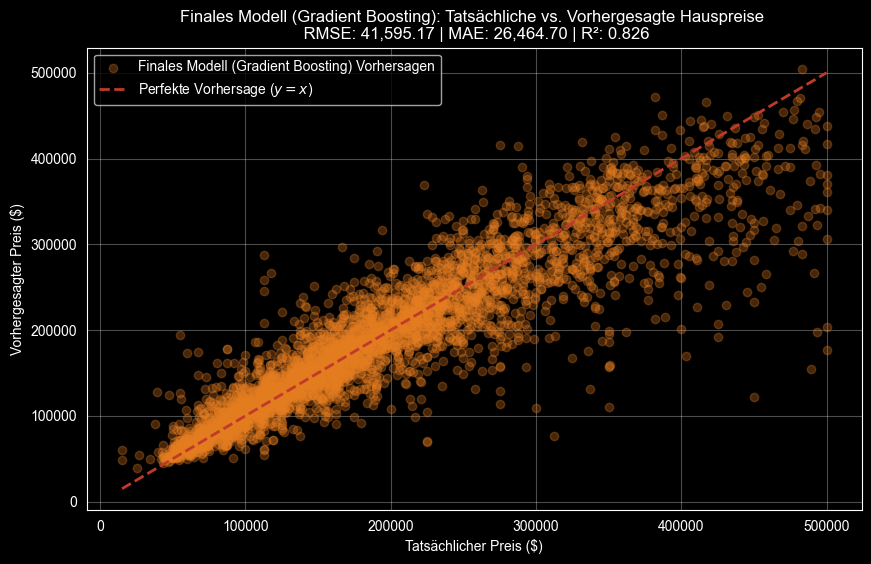

In [716]:
plot_actual_vs_predicted(y_test, y_test_pred, 'Finales Modell (Gradient Boosting)', '#e67e22')

## 8. Feature Importance (Interpretation)

Ein großer Vorteil baumbasierter Modelle ist die Interpretierbarkeit. Wir können analysieren, welche Variablen den Algorithmus am meisten bei der Preisfindung beeinflusst haben. Wie erwartet sehen wir, dass das mittlere Einkommen (`median_income`) sowie unsere neu erstellten räumlichen Merkmale (`dist_to_LA`, `dist_to_SF` und geografische Cluster) die wichtigsten Indikatoren für den Hauspreis sind.

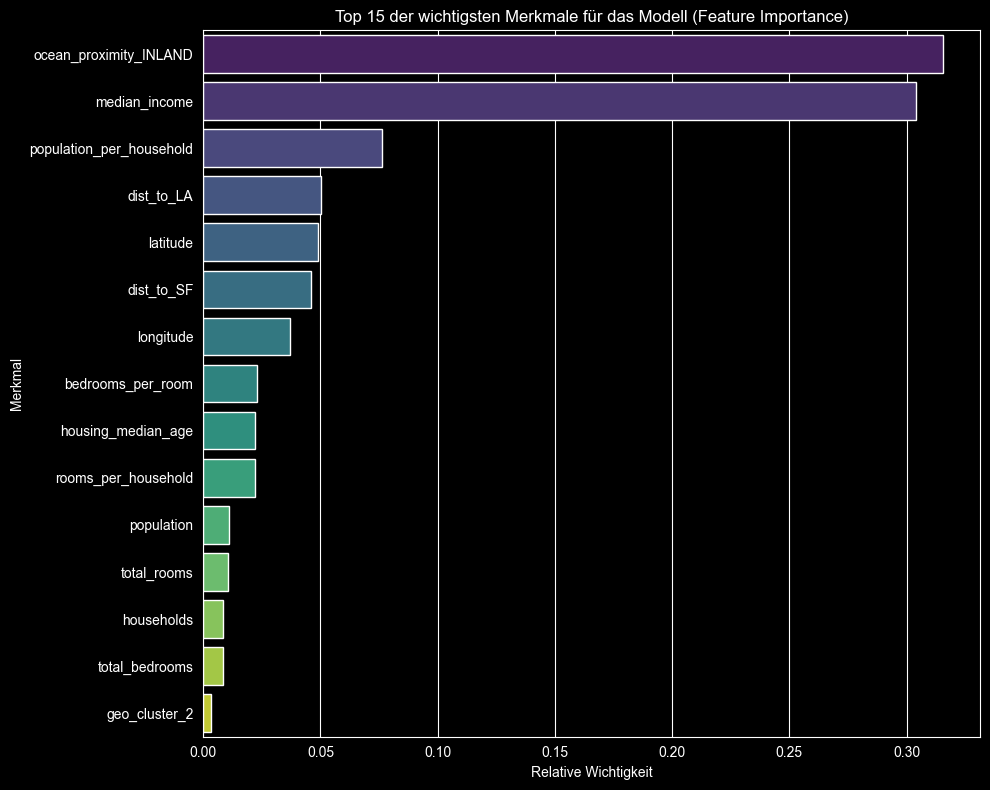

In [717]:
import pandas as pd

# Extrahieren des trainierten Modells aus dem TransformedTargetRegressor
trained_gb = full_pipeline.named_steps['model'].regressor_

# Extrahieren der Feature-Namen nach dem Preprocessing (OneHotEncoding generiert neue Spalten)
cat_encoder = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_onehot_features = cat_encoder.get_feature_names_out(cat_features).tolist()
all_features = num_features + cat_onehot_features

# DataFrame für die Feature Importance erstellen
feature_importances = pd.DataFrame({
    'Merkmal': all_features,
    'Wichtigkeit': trained_gb.feature_importances_
}).sort_values(by='Wichtigkeit', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Wichtigkeit',
    y='Merkmal',
    data=feature_importances.head(15),
    palette="viridis",
    hue='Merkmal',
    legend=False
)
plt.title('Top 15 der wichtigsten Merkmale für das Modell (Feature Importance)')
plt.xlabel('Relative Wichtigkeit')
plt.ylabel('Merkmal')
plt.tight_layout()
plt.show()